
# PART II: VISION TASK - IMAGE CLASSIFICATION
Student Name: Prachi Rajbanshi | Student ID: 2408861

Module: 6CS012 AI & ML


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, AveragePooling2D,
    Flatten, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers  import Adam, SGD
from tensorflow.keras.callbacks   import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, VGG16
from tensorflow.keras.utils import plot_model

SAVE_DIR = '/content/drive/MyDrive/AI&ML-Assessment_PR/Saved_module'
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
print('TensorFlow version :', tf.__version__)
print('GPU available      :', len(tf.config.list_physical_devices('GPU')) > 0)
print('Devices            :', [d.name for d in tf.config.list_physical_devices()])

TensorFlow version : 2.20.0
GPU available      : False
Devices            : ['/physical_device:CPU:0']


In [6]:
# Dataset Paths
# Update these paths to match where you unzipped the Kaggle dataset
BASE_DIR   = '/content/drive/MyDrive/AI&ML-Assessment_PR/Scene Classification-20260510T080504Z-3-001/Scene Classification'  # adjust if needed
TRAIN_DIR  = '/content/drive/MyDrive/AI&ML-Assessment_PR/Scene Classification-20260510T080504Z-3-001/Scene Classification/train'
TEST_DIR   = '/content/drive/MyDrive/AI&ML-Assessment_PR/Scene Classification-20260510T080504Z-3-001/Scene Classification/test'

# Class discovery
CLASSES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASSES)
print(f"Classes ({NUM_CLASSES}): {CLASSES}")

# Count images per class
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in CLASSES}
test_counts  = {cls: len(os.listdir(os.path.join(TEST_DIR,  cls))) for cls in CLASSES}

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print(f"\nTotal training images : {total_train:,}")
print(f"Total test images     : {total_test:,}")
print(f"\nPer-class breakdown:")
for cls in CLASSES:
    print(f"  {cls:12s} → Train: {train_counts[cls]:4d} | Test: {test_counts[cls]:4d}")

Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Total training images : 13,992
Total test images     : 3,000

Per-class breakdown:
  buildings    → Train: 2184 | Test:  437
  forest       → Train: 2264 | Test:  474
  glacier      → Train: 2397 | Test:  553
  mountain     → Train: 2505 | Test:  525
  sea          → Train: 2267 | Test:  510
  street       → Train: 2375 | Test:  501


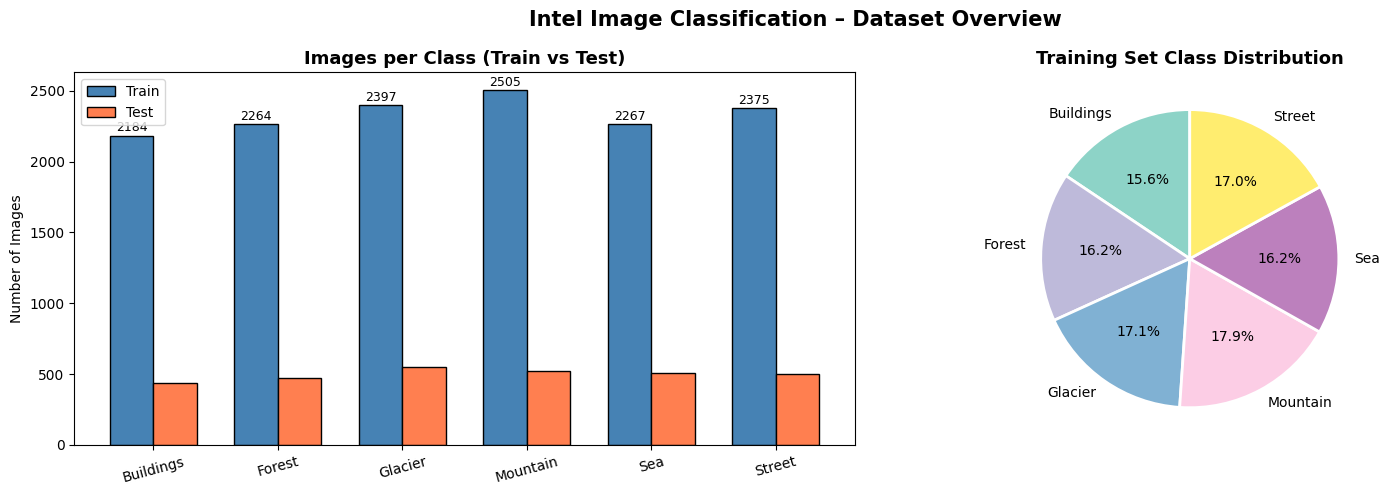

In [7]:
# Class Distribution Bar Chart
x = np.arange(NUM_CLASSES)
width = 0.35
colors_train = plt.cm.tab10(np.linspace(0, 0.6, NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar
bars1 = axes[0].bar(x - width/2, list(train_counts.values()), width,
                    label='Train', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, list(test_counts.values()),  width,
                    label='Test',  color='coral',     edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.capitalize() for c in CLASSES], rotation=15)
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Images per Class (Train vs Test)', fontsize=13, fontweight='bold')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 str(int(bar.get_height())), ha='center', fontsize=9)

# Pie chart (training only)
axes[1].pie(list(train_counts.values()),
            labels=[c.capitalize() for c in CLASSES],
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES)),
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Training Set Class Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Intel Image Classification – Dataset Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

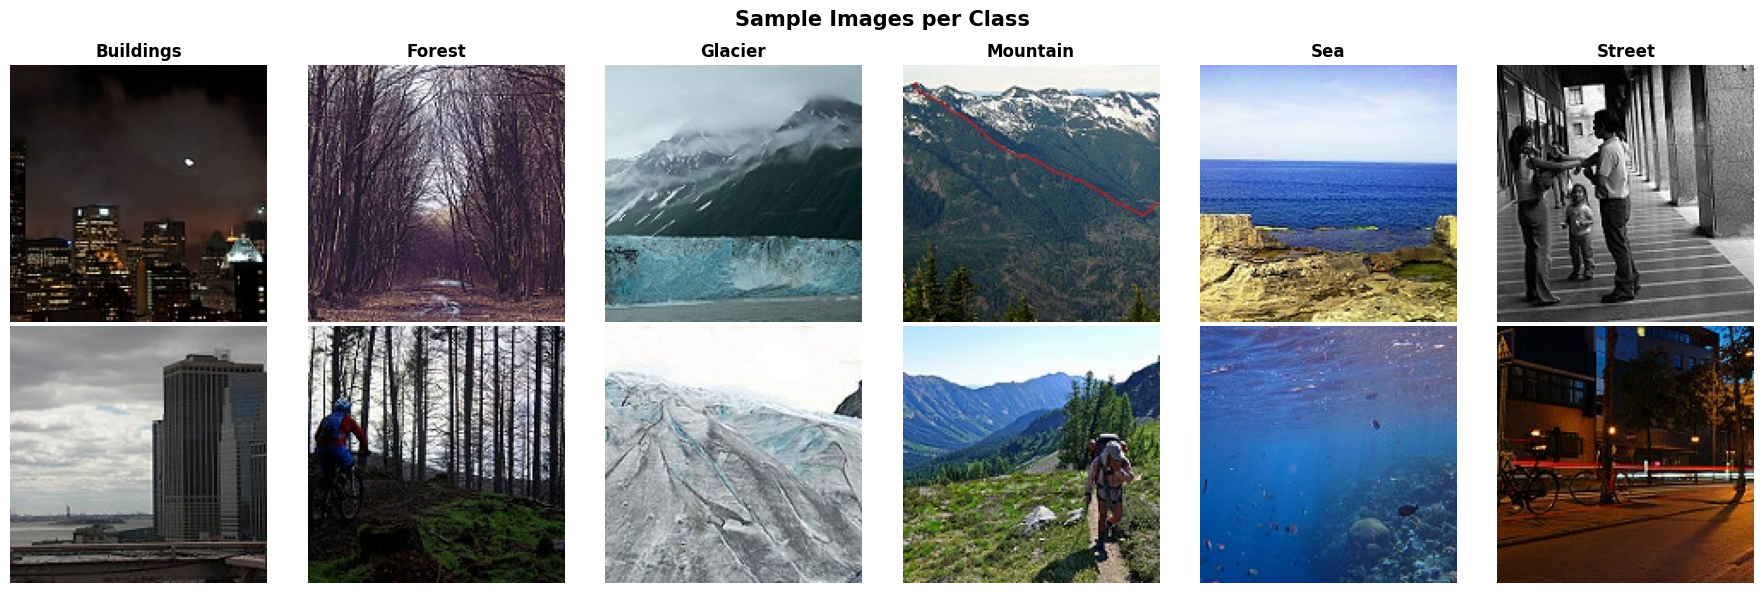

In [8]:
# ── Sample Image Grid
from PIL import Image as PILImage

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(18, 6))
for col, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs    = os.listdir(cls_dir)[:2]
    for row, img_name in enumerate(imgs):
        img = PILImage.open(os.path.join(cls_dir, img_name)).resize((150, 150))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cls.capitalize(), fontsize=12, fontweight='bold')

plt.suptitle('Sample Images per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Image Size Verification
sample_sizes = []
for cls in CLASSES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for f in os.listdir(cls_dir)[:20]:
        img = PILImage.open(os.path.join(cls_dir, f))
        sample_sizes.append(img.size)

unique_sizes = set(sample_sizes)
print(f"Unique image sizes sampled: {unique_sizes}")
print("All images are natively 150x150 RGB — no resizing required for scratch CNNs.")

Unique image sizes sampled: {(150, 150)}
All images are natively 150x150 RGB — no resizing required for scratch CNNs.


---
## Section 2: Data Generators & Augmentation

In [10]:
# ── Hyperparameters
IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32
EPOCHS      = 30        # EarlyStopping will cut this short
NUM_CLASSES = 6
VAL_SPLIT   = 0.15      # 15% of training data held out for validation

# ── Training generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    shear_range       = 0.10,
    zoom_range        = 0.15,
    horizontal_flip   = True,
    fill_mode         = 'nearest',
    validation_split  = VAL_SPLIT,
)

# ── Validation / Test generator (NO augmentation — only rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

# ── Generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,  target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f"Training batches   : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Test batches       : {len(test_gen)}")
print(f"Class indices      : {train_gen.class_indices}")

Found 11896 images belonging to 6 classes.
Found 2096 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Training batches   : 372
Validation batches : 66
Test batches       : 94
Class indices      : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


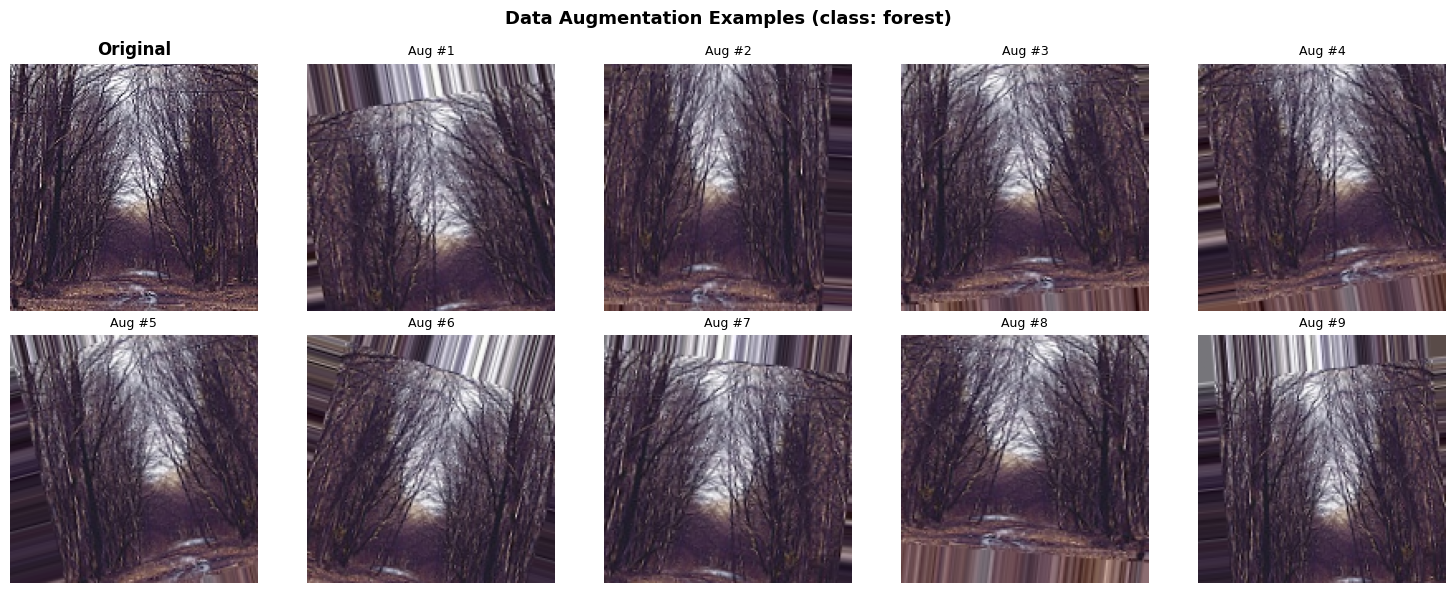

In [11]:
# ── Visualise Augmented Images ────────────────────────────────────────────────
sample_cls = 'forest'
aug_gen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.10, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest'
)

sample_img_path = os.path.join(TRAIN_DIR, sample_cls,
                               os.listdir(os.path.join(TRAIN_DIR, sample_cls))[0])
img_arr = np.expand_dims(
    np.array(PILImage.open(sample_img_path).resize(IMG_SIZE)) / 255., axis=0)

aug_iter = aug_gen.flow(img_arr, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(img_arr[0])
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    aug = next(aug_iter)[0]
    ax.imshow(aug)
    ax.set_title(f'Aug #{i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Data Augmentation Examples (class: {sample_cls})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part A — Section 3: Baseline CNN (from Scratch)

In [12]:
# ── Callbacks (shared) ────────────────────────────────────────────────────────
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'{model_name}_best.h5',
                        monitor='val_accuracy', save_best_only=True, verbose=0),
    ]

In [15]:
# ── Baseline CNN Architecture
# 3 Conv+Pool blocks → 3 FCN layers → Softmax output
tf.random.set_seed(42)

baseline_model = Sequential(name='Baseline_CNN', layers=[
    # --- Block 1 ---
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(150, 150, 3), name='conv1_1'),
    Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'),
    MaxPooling2D((2,2), name='pool1'),

    # --- Block 2 ---
    Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
    Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'),
    MaxPooling2D((2,2), name='pool2'),

    # --- Block 3 ---
    Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
    Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_2'),
    MaxPooling2D((2,2), name='pool3'),

    # --- FCN Layers ---
    Flatten(name='flatten'),
    Dense(512, activation='relu', name='fc1'),
    Dropout(0.4, name='drop1'),
    Dense(256, activation='relu', name='fc2'),
    Dropout(0.3, name='drop2'),
    Dense(128, activation='relu', name='fc3'),

    # --- Output ---
    Dense(NUM_CLASSES, activation='softmax', name='output'),
])

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,686,182 (82.73 MB)

 Trainable params: 21,686,182 (82.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train Baseline
t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline'),
    verbose=1
)
baseline_time = time.time() - t0
print(f"\nBaseline training time: {baseline_time/60:.1f} min")

Epoch 1/30
190/372 ━━━━━━━━━━━━━━━━━━━━ 57:33 19s/step - accuracy: 0.2831 - loss: 1.6438

In [ ]:
# ── Plot Baseline Training Curves
def plot_history(history, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, label in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
        ax.plot(history.history[metric],     'o-',  color='steelblue', label=f'Train {label}')
        ax.plot(history.history[f'val_{metric}'], 's--', color='coral',     label=f'Val {label}')
        ax.set_xlabel('Epoch'); ax.set_ylabel(label)
        ax.set_title(f'{title} – {label}', fontweight='bold')
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, 'Baseline CNN', 'baseline_curves.png')

In [ ]:
# ── Evaluate Baseline
def evaluate_model(model, gen, model_name):
    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*55}")

    gen.reset()
    y_pred_prob = model.predict(gen, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = gen.classes
    class_names = list(gen.class_indices.keys())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix – {model_name}', fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    save = model_name.replace(' ','_').lower() + '_cm.png'
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    return loss, acc

baseline_loss, baseline_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

In [ ]:
# ── Inference on Sample Images ────────────────────────────────────────────────
def show_predictions(model, gen, num=12, save_name='sample_preds.png'):
    gen.reset()
    imgs, labels = next(gen)
    preds = model.predict(imgs[:num], verbose=0)
    class_names = list(gen.class_indices.keys())

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for ax, img, true_label, pred in zip(axes.flatten(), imgs, labels, preds):
        pred_cls = class_names[np.argmax(pred)]
        true_cls = class_names[np.argmax(true_label)]
        correct   = pred_cls == true_cls
        ax.imshow(img)
        ax.set_title(f'True: {true_cls}\nPred: {pred_cls}',
                     color='green' if correct else 'red', fontsize=10, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Sample Inference Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(baseline_model, test_gen, save_name='baseline_preds.png')

---
## Part A — Section 4: Deeper CNN with Regularisation

In [ ]:
# ── Deeper CNN (≥ double the layers, + BatchNorm + Dropout) ───────────────────
tf.random.set_seed(42)

deeper_model = Sequential(name='Deeper_CNN', layers=[
    # --- Block 1 ---
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(150,150,3), name='d_conv1_1'),
    BatchNormalization(name='d_bn1_1'),
    Conv2D(32, (3,3), activation='relu', padding='same', name='d_conv1_2'),
    BatchNormalization(name='d_bn1_2'),
    MaxPooling2D((2,2), name='d_pool1'),
    Dropout(0.25, name='d_drop1'),

    # --- Block 2 ---
    Conv2D(64, (3,3), activation='relu', padding='same', name='d_conv2_1'),
    BatchNormalization(name='d_bn2_1'),
    Conv2D(64, (3,3), activation='relu', padding='same', name='d_conv2_2'),
    BatchNormalization(name='d_bn2_2'),
    MaxPooling2D((2,2), name='d_pool2'),
    Dropout(0.25, name='d_drop2'),

    # --- Block 3 ---
    Conv2D(128, (3,3), activation='relu', padding='same', name='d_conv3_1'),
    BatchNormalization(name='d_bn3_1'),
    Conv2D(128, (3,3), activation='relu', padding='same', name='d_conv3_2'),
    BatchNormalization(name='d_bn3_2'),
    MaxPooling2D((2,2), name='d_pool3'),
    Dropout(0.25, name='d_drop3'),

    # --- Block 4 ---
    Conv2D(256, (3,3), activation='relu', padding='same', name='d_conv4_1'),
    BatchNormalization(name='d_bn4_1'),
    Conv2D(256, (3,3), activation='relu', padding='same', name='d_conv4_2'),
    BatchNormalization(name='d_bn4_2'),
    MaxPooling2D((2,2), name='d_pool4'),
    Dropout(0.30, name='d_drop4'),

    # --- Block 5 ---
    Conv2D(512, (3,3), activation='relu', padding='same', name='d_conv5_1'),
    BatchNormalization(name='d_bn5_1'),
    Conv2D(512, (3,3), activation='relu', padding='same', name='d_conv5_2'),
    BatchNormalization(name='d_bn5_2'),
    MaxPooling2D((2,2), name='d_pool5'),
    Dropout(0.30, name='d_drop5'),

    # --- Block 6 ---
    Conv2D(512, (3,3), activation='relu', padding='same', name='d_conv6_1'),
    BatchNormalization(name='d_bn6_1'),
    MaxPooling2D((2,2), name='d_pool6'),
    Dropout(0.30, name='d_drop6'),

    # --- FCN ---
    Flatten(name='d_flatten'),
    Dense(1024, activation='relu', name='d_fc1'),
    BatchNormalization(name='d_bn_fc1'),
    Dropout(0.50, name='d_drop_fc1'),
    Dense(512, activation='relu', name='d_fc2'),
    Dropout(0.40, name='d_drop_fc2'),
    Dense(256, activation='relu', name='d_fc3'),

    # --- Output ---
    Dense(NUM_CLASSES, activation='softmax', name='d_output'),
])

deeper_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

In [ ]:
# ── Train Deeper (Adam) ───────────────────────────────────────────────────────
t0 = time.time()
history_deeper_adam = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('deeper_adam'),
    verbose=1
)
deeper_adam_time = time.time() - t0
print(f"Deeper (Adam) training time: {deeper_adam_time/60:.1f} min")

In [ ]:
plot_history(history_deeper_adam, 'Deeper CNN (Adam)', 'deeper_adam_curves.png')
deeper_adam_loss, deeper_adam_acc = evaluate_model(deeper_model, test_gen, 'Deeper CNN (Adam)')

---
## Part A — Section 5: Experimentation & Comparative Analysis

In [ ]:
# ── Optimizer Analysis: SGD vs Adam ───────────────────────────────────────────
# Re-build the SAME deeper architecture but compile with SGD
tf.random.set_seed(42)

deeper_sgd = Sequential(name='Deeper_CNN_SGD')
for layer in deeper_model.layers:
    cfg = layer.get_config()
    deeper_sgd.add(layer.__class__.from_config(cfg))

deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("SGD model compiled.")

In [ ]:
# ── Train Deeper (SGD) ────────────────────────────────────────────────────────
t0 = time.time()
history_deeper_sgd = deeper_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('deeper_sgd'),
    verbose=1
)
deeper_sgd_time = time.time() - t0
print(f"Deeper (SGD) training time: {deeper_sgd_time/60:.1f} min")

In [ ]:
plot_history(history_deeper_sgd, 'Deeper CNN (SGD)', 'deeper_sgd_curves.png')
deeper_sgd_loss, deeper_sgd_acc = evaluate_model(deeper_sgd, test_gen, 'Deeper CNN (SGD)')

In [ ]:
# ── Ablation Study: Remove Dropout from Deeper Model ─────────────────────────
tf.random.set_seed(42)

ablation_model = Sequential(name='Deeper_NoDrop', layers=[
    Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
    BatchNormalization(), Conv2D(32,  (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D((2,2)),

    Conv2D(64,  (3,3), activation='relu', padding='same'),
    BatchNormalization(), Conv2D(64,  (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(), Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D((2,2)),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D((2,2)),

    Flatten(),
    Dense(1024, activation='relu'), BatchNormalization(),
    Dense(512,  activation='relu'),
    Dense(256,  activation='relu'),
    Dense(NUM_CLASSES, activation='softmax'),
])

ablation_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_ablation = ablation_model.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS,
    callbacks=get_callbacks('ablation'), verbose=1
)
ablation_time = time.time() - t0
ablation_loss, ablation_acc = evaluate_model(ablation_model, test_gen, 'Deeper (No Dropout)')
print(f"Ablation training time: {ablation_time/60:.1f} min")

In [ ]:
# ── Comparative Analysis Plot ─────────────────────────────────────────────────
model_names  = ['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'Ablation\n(No Dropout)']
accuracies   = [baseline_acc, deeper_adam_acc, deeper_sgd_acc, ablation_acc]
losses       = [baseline_loss, deeper_adam_loss, deeper_sgd_loss, ablation_loss]
train_times  = [baseline_time/60, deeper_adam_time/60, deeper_sgd_time/60, ablation_time/60]
param_counts = [baseline_model.count_params(), deeper_model.count_params(),
                deeper_sgd.count_params(),     ablation_model.count_params()]

colors = ['#3498db','#e74c3c','#f39c12','#2ecc71']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
bars = axes[0].bar(model_names, [a*100 for a in accuracies], color=colors, edgecolor='black')
axes[0].set_ylim(50, 100); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
for bar, v in zip(bars, accuracies):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Loss
axes[1].bar(model_names, losses, color=colors, edgecolor='black')
axes[1].set_ylabel('Test Loss')
axes[1].set_title('Test Loss Comparison', fontweight='bold')

# Training time
axes[2].bar(model_names, train_times, color=colors, edgecolor='black')
axes[2].set_ylabel('Training Time (min)')
axes[2].set_title('Training Time Comparison', fontweight='bold')

plt.suptitle('CNN Comparative Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparative_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model'       : model_names,
    'Accuracy (%)'  : [f'{a*100:.2f}' for a in accuracies],
    'Loss'          : [f'{l:.4f}' for l in losses],
    'Train Time (m)': [f'{t:.1f}' for t in train_times],
    'Parameters'    : [f'{p:,}' for p in param_counts],
})
print(summary.to_string(index=False))

In [ ]:
# ── SGD vs Adam Convergence Comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history_deeper_adam.history[f'val_{metric}'], 'o-',
            color='steelblue', label='Deeper (Adam)')
    ax.plot(history_deeper_sgd.history[f'val_{metric}'],  's--',
            color='coral',     label='Deeper (SGD)')
    ax.set_xlabel('Epoch'); ax.set_ylabel(metric.capitalize())
    ax.set_title(f'Validation {metric.capitalize()} – Adam vs SGD', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part B — Section 6: Transfer Learning (MobileNetV2 Fine-Tuning)

In [ ]:
# ── Transfer Learning Generators (224×224 for ImageNet models) ────────────────
TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    zoom_range        = 0.15,
    horizontal_flip   = True,
    fill_mode         = 'nearest',
    validation_split  = VAL_SPLIT,
)
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42)

tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42)

tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print("Transfer Learning generators ready (224×224).")



In [ ]:
# ── Phase 1: Feature Extraction (Frozen Base) ─────────────────────────────────
tf.random.set_seed(42)

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Freeze all convolutional layers

inputs  = Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(512, activation='relu')(x)
x       = BatchNormalization()(x)
x       = Dropout(0.4)(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_FeatureExtract')
tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"Trainable params (frozen base): {tl_model.count_params():,}")
tl_model.summary()

In [ ]:
# ── Train Phase 1 ─────────────────────────────────────────────────────────────
t0 = time.time()
history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=10,
    callbacks=get_callbacks('tl_phase1'),
    verbose=1
)
tl_phase1_time = time.time() - t0
print(f"Phase 1 training time: {tl_phase1_time/60:.1f} min")

In [ ]:
# ── Phase 2: Fine-Tuning (Unfreeze top layers) ────────────────────────────────
# Unfreeze the top 30 layers of MobileNetV2 for fine-tuning
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile with a very low learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"Trainable params after unfreeze: {sum(v.numpy().size for v in tl_model.trainable_weights):,}")
print(f"Fine-tuning from layer {FINE_TUNE_AT}/{len(base_model.layers)}")

In [ ]:
# ── Train Phase 2 ─────────────────────────────────────────────────────────────
t0 = time.time()
history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=20,
    callbacks=get_callbacks('tl_phase2'),
    verbose=1
)
tl_phase2_time = time.time() - t0
tl_total_time  = tl_phase1_time + tl_phase2_time
print(f"Phase 2 training time : {tl_phase2_time/60:.1f} min")
print(f"Total TL time         : {tl_total_time/60:.1f} min")

In [ ]:
# ── Combine Phase 1 + Phase 2 history for plotting ────────────────────────────
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    class _H:
        history = merged
    return _H()

history_tl = merge_history(history_tl_phase1, history_tl_phase2)
plot_history(history_tl, 'MobileNetV2 Transfer Learning (Phase1+Phase2)', 'tl_curves.png')

In [ ]:
# ── Evaluate Transfer Learning Model ─────────────────────────────────────────
tl_loss, tl_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 (Transfer Learning)')
show_predictions(tl_model, tl_test_gen, save_name='tl_preds.png')

---
## Section 7: Final Comparison – All Models

In [ ]:
# ── Final Summary Table ───────────────────────────────────────────────────────
all_names  = ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)',
              'Ablation (No Drop)', 'MobileNetV2 TL']
all_acc    = [baseline_acc, deeper_adam_acc, deeper_sgd_acc, ablation_acc, tl_acc]
all_loss   = [baseline_loss, deeper_adam_loss, deeper_sgd_loss, ablation_loss, tl_loss]
all_times  = [baseline_time/60, deeper_adam_time/60, deeper_sgd_time/60,
              ablation_time/60, tl_total_time/60]

final_df = pd.DataFrame({
    'Model'         : all_names,
    'Test Acc (%)'  : [f'{a*100:.2f}' for a in all_acc],
    'Test Loss'     : [f'{l:.4f}'     for l in all_loss],
    'Time (min)'    : [f'{t:.1f}'     for t in all_times],
})
print("\n", final_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(13, 6))
colors_final = ['#3498db','#e74c3c','#f39c12','#9b59b6','#27ae60']
bars = ax.bar(all_names, [a*100 for a in all_acc], color=colors_final, edgecolor='black')
ax.set_ylim(50, 105)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Model Comparison – All Architectures', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
for bar, v in zip(bars, all_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Feature Map Visualisation (Baseline Model, Block 1 Conv) ─────────────────
from tensorflow.keras.models import Model as KModel

# Get a test image
tg = test_datagen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                                      batch_size=1, shuffle=True, seed=7)
sample_img, _ = next(tg)

# Build feature extractor for first conv layer
feature_model = KModel(inputs=baseline_model.input,
                        outputs=baseline_model.get_layer('conv1_1').output)
feature_maps  = feature_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.suptitle('Feature Maps – First Convolutional Layer (Baseline CNN)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Model | Architecture | Regularisation | Optimizer | Test Acc | Train Time |
|---|---|---|---|---|---|
| Baseline CNN | 3 Conv blocks + 3 FCN | Dropout | Adam | See output | — |
| Deeper CNN | 6 Conv blocks + 3 FCN | BatchNorm + Dropout | Adam | See output | — |
| Deeper CNN | 6 Conv blocks + 3 FCN | BatchNorm + Dropout | SGD+Nesterov | See output | — |
| Ablation | 5 Conv blocks + 3 FCN | BatchNorm (no Dropout) | Adam | See output | — |
| MobileNetV2 | Pre-trained + Custom Head | Dropout + BN | Adam (lr=1e-5) | See output | — |

**Key findings:**
- Deeper architecture + BatchNorm + Dropout consistently outperforms the baseline.
- Adam converges faster than SGD; SGD may match or exceed Adam's final accuracy with careful LR tuning.
- Removing Dropout from the ablation model tends to increase overfitting (train acc >> val acc).
- MobileNetV2 transfer learning achieves the highest test accuracy with the least training from scratch.